In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
stock = yf.Ticker('AAPL')
stock.options

('2026-07-24',
 '2026-07-27',
 '2026-07-29',
 '2026-07-31',
 '2026-08-07',
 '2026-08-14',
 '2026-08-21',
 '2026-08-28',
 '2026-09-18',
 '2026-10-16',
 '2026-11-20',
 '2026-12-18',
 '2027-01-15',
 '2027-02-19',
 '2027-03-19',
 '2027-06-17',
 '2027-09-17',
 '2027-12-17',
 '2028-01-21',
 '2028-03-17',
 '2028-12-15')

In [11]:
opt_chain = stock.option_chain('2026-07-31')
calls = opt_chain.calls
puts = opt_chain.puts

In [12]:
hist = stock.history(period = '1y')
hist.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-07-23 00:00:00-04:00,214.150419,214.299820,211.570657,213.303772,46989300,0.0,0.0
2025-07-24 00:00:00-04:00,213.054775,214.837711,212.686242,212.915329,46022600,0.0,0.0
2025-07-25 00:00:00-04:00,213.851588,214.389462,212.556722,213.034836,40268800,0.0,0.0
2025-07-28 00:00:00-04:00,213.184253,214.001020,212.218084,213.204178,37858000,0.0,0.0
2025-07-29 00:00:00-04:00,213.333655,213.961170,209.986947,210.435165,51411700,0.0,0.0


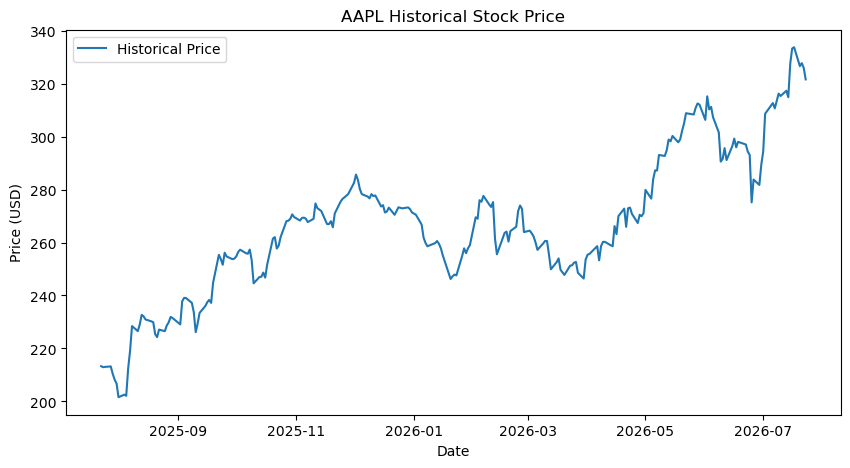

In [15]:
prices = hist['Close']
plt.figure(figsize = (10,5))
plt.plot(prices, label = "Historical Price")
plt.title(f"{'AAPL'} Historical Stock Price") 
plt.xlabel("Date")                     
plt.ylabel("Price (USD)")              
plt.legend()                           
plt.show()  

In [20]:
log_returns = np.log(prices/prices.shift(1)) 
log_returns = log_returns.dropna()
mu = log_returns.mean()
sigma = log_returns.std()

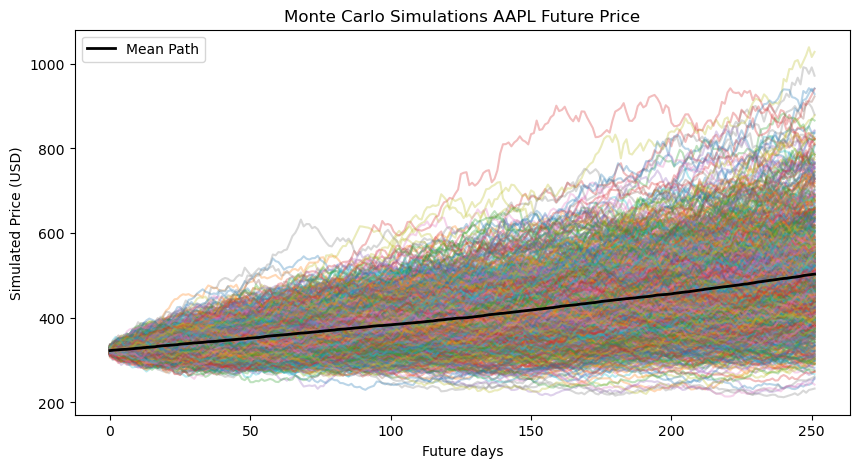

In [24]:
#Monte Carlo simulation
lastprice = prices.iloc[-1]
simulations = 1000
days = 252

simulation_df = np.zeros((days, simulations))

for s in range(simulations):
    price_series = [lastprice]

    for day in range(days):
        random_return = np.random.normal(mu, sigma)

        price_today = price_series[-1] * np.exp(random_return)
        price_series.append(price_today)
        
    simulation_df[:, s] = price_series[1:]
    
mean_path = simulation_df.mean(axis=1)        
plt.figure(figsize = (10,5))
plt.plot(simulation_df, alpha =0.3)
plt.plot(mean_path, color='black', linewidth=2, label='Mean Path')
plt.title(f"Monte Carlo Simulations {'AAPL'} Future Price") 
plt.xlabel("Future days")                     
plt.ylabel("Simulated Price (USD)")
plt.legend()
plt.show()